## Chapter 1: Data

##### Repeating the stages completed in the main analysis in chapters 1 and 2, we ETL the dataset to be used by the tool.

In [2]:
import pandas as pd
import osmnx as ox
import geopandas as gpd
import re
from pathlib import Path
import requests
from bs4 import BeautifulSoup
import json
import time
import matplotlib.pyplot as plt
from shapely.geometry import Point
import numpy as np
from sklearn.preprocessing import MinMaxScaler
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
from shapely import wkt
from shapely.geometry import Polygon
import h3
import matplotlib.colors as mcolors

In [3]:
df = pd.read_csv("warsaw_rent_clean_2903.csv")

In [4]:
MIN_SAMPLES = 5

reported = df[df["czynsz"].notna()].copy()

l1 = (
    reported[reported["czynsz"] > 0]
    .groupby(["district", "rooms"])["czynsz"]
    .agg(median="median", count="count")
    .reset_index()
)
l1_valid = l1[l1["count"] >= MIN_SAMPLES].set_index(["district", "rooms"])["median"]

l2 = (
    reported[reported["czynsz"] > 0]
    .groupby("rooms")["czynsz"]
    .agg(median="median", count="count")
    .reset_index()
)
l2_valid = l2[l2["count"] >= MIN_SAMPLES].set_index("rooms")["median"]

l3 = reported.loc[reported["czynsz"] > 0, "czynsz"].median()

print(f"Level 3 median: {l3:.0f} PLN")

def impute_row(row):
    if pd.notna(row["czynsz"]) and row["czynsz"] > 0:
        return row["czynsz"], "original"

    district = row.get("district")
    rooms    = row.get("rooms")
    
    if pd.notna(district) and pd.notna(rooms):
        key = (district, rooms)
        if key in l1_valid.index:
            return l1_valid[key], "district+rooms"

    if pd.notna(rooms) and rooms in l2_valid.index:
        return l2_valid[rooms], "rooms"

    return l3, "overall"

results = df.apply(impute_row, axis=1, result_type="expand")
results.columns = ["czynsz_imputed", "czynsz_source"]

df = pd.concat([df, results], axis=1)

df["total_monthly"] = df["price"] + df["czynsz_imputed"]

print(f"\n{df['czynsz_source'].value_counts().to_string()}")

Level 3 median: 750 PLN

czynsz_source
original          1159
district+rooms     158


In [5]:
df = df[["title", "total_monthly", "area", "rooms", "price_per_m2", "latitude", "longitude", "url"]].dropna(subset=["latitude", "longitude"])
df = df[(df["latitude"] != 0) & (df["longitude"] != 0)][(df["rooms"] <= 2)]

gdf_listings = gpd.GeoDataFrame(df[["title", "total_monthly", "area", "rooms", "price_per_m2", "url"]], geometry=gpd.points_from_xy(df.longitude, df.latitude), crs="EPSG:4326")

gdf_listings = gdf_listings[(gdf_listings.geometry.x.between(20.8, 21.3)) & (gdf_listings.geometry.y.between(52.1, 52.4))]

gdf_listings.head()

,title,total_monthly,area,rooms,price_per_m2,url,geometry
0,"Przestronna kawalerka, metro Dworzec Gdański",3900.0,38.0,2,81.578947,https://www.otodom.pl/pl/oferta/przestronna-ka...,POINT (20.99358 52.2569)
1,"Nowoczesna duża kawalerka, ul. Szeligowska, Be...",3770.0,33.0,1,96.969697,https://www.otodom.pl/pl/oferta/nowoczesna-duz...,POINT (20.88063 52.22795)
2,Mieszkania WARSZAWA dla studentów oraz młodych...,3550.0,20.0,1,147.500000,https://www.otodom.pl/pl/oferta/mieszkania-war...,POINT (21.0064 52.25903)
3,Nowe mieszkanie 2 zamykane pokoje oddzielna ku...,3770.0,44.1,2,70.294785,https://www.otodom.pl/pl/oferta/nowe-mieszkani...,POINT (20.88502 52.22757)
4,"2 pok., wyposażone, klimatyzacja, TV, garaż, u...",4300.0,40.0,2,90.000000,https://www.otodom.pl/pl/oferta/2-pok-wyposazo...,POINT (20.88932 52.22749)


In [6]:
gdf_listings["flat_type"] = gdf_listings["area"].apply(
    lambda a: "solo" if a <= 40 else ("shareable" if a >= 50 else "ambiguous")
)
print(gdf_listings["flat_type"].value_counts())

flat_type
solo         627
ambiguous    420
shareable    270
Name: count, dtype: int64


In [7]:
solo_shareable_gdf = gdf_listings[gdf_listings["flat_type"].isin(["shareable", "solo"])]
gdf_listings = solo_shareable_gdf

In [8]:
universities = ox.features_from_place("Warsaw, Poland", tags={'amenity': ['university'], 'building': ['university']})
mapping = pd.read_csv("universities_map.csv")

gdf_universities = gpd.GeoDataFrame(universities, geometry="geometry", crs="EPSG:4326")

gdf_universities = gdf_universities[["name", "geometry"]]
gdf_universities["latitude"] = gdf_universities.geometry.centroid.y
gdf_universities["longitude"] = gdf_universities.geometry.centroid.x

results = []
not_found = []

for _, map_row in mapping.iterrows():
    university  = map_row["university"]
    bname       = map_row["building_name"]
    is_main     = map_row["is_main"]

    matches = gdf_universities[gdf_universities["name"] == bname]

    if matches.empty:
        not_found.append((university, bname))
        continue

    lat = matches["latitude"].mean()
    lon = matches["longitude"].mean()

    results.append({
        "university":    university,
        "building_name": bname,
        "is_main":       is_main,
        "latitude":      round(lat, 7),
        "longitude":     round(lon, 7),
    })

gdf_universities = pd.DataFrame(results)

gdf_universities["_sort"] = gdf_universities["is_main"].map({True: 0, False: 1})
gdf_universities = (gdf_universities
                     .sort_values(["university", "_sort", "building_name"])
                     .drop(columns="_sort")
                     .reset_index(drop=True))

gdf_universities = gpd.GeoDataFrame(gdf_universities[["university", "building_name", "is_main"]], geometry=gpd.points_from_xy(gdf_universities.longitude, gdf_universities.latitude), crs="EPSG:4326")

print(f"Map entries:  {len(mapping)} rows across "
      f"{mapping['university'].nunique()} universities")

gdf_universities.head()

C:\Users\PlaySpace\AppData\Local\Temp\ipykernel_1196\655733835.py:7: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf_universities["latitude"] = gdf_universities.geometry.centroid.y
C:\Users\PlaySpace\AppData\Local\Temp\ipykernel_1196\655733835.py:8: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf_universities["longitude"] = gdf_universities.geometry.centroid.x


Map entries:  161 rows across 20 universities


,university,building_name,is_main,geometry
0,Akademia Finansów i Biznesu Vistula,Akademia Finansów i Biznesu Vistula,True,POINT (21.03397 52.15882)
1,Akademia Leona Koźmińskiego,Akademia Leona Koźmińskiego,True,POINT (21.01395 52.2715)
2,Akademia Pedagogiki Specjalnej,Akademia Pedagogiki Specjalnej im. Marii Grzeg...,True,POINT (20.96993 52.21718)
3,Akademia Pedagogiki Specjalnej,Instytut Edukacji Artystycznej Akademii Pedago...,False,POINT (20.98386 52.22249)
4,Akademia Pożarnicza,Akademia Pożarnicza,True,POINT (20.97658 52.27198)


In [9]:
metro_stations = ox.features_from_place("Warsaw, Poland", tags={"railway": "station", "station": "metro"})

metro_stations = metro_stations[metro_stations["network"].isin(["Warsaw Metro", "Metro Warszawskie"])][["name", "geometry"]]

gdf_metro = gpd.GeoDataFrame(metro_stations, geometry="geometry", crs="EPSG:4326")

gdf_metro.head()

name                   geometry
element id                                                  
node    35121250   Ratusz-Arsenał  POINT (21.00088 52.24522)
        291414851        Marymont  POINT (20.97194 52.27158)
        307389114   Stare Bielany  POINT (20.94935 52.28183)
        307389115      Wawrzyszew  POINT (20.93952 52.28635)
        307389116         Młociny  POINT (20.92987 52.29077)

In [10]:
gdf_districts = gpd.read_file("warszawa-dzielnice.geojson")

gdf_districts = gdf_districts[gdf_districts["name"] != "Warszawa"].to_crs("EPSG:4326")[gdf_districts["name"] != "Warszawa"]

gdf_districts["district_name"] = gdf_districts["name"]
gdf_districts = gdf_districts[["district_name", "geometry"]]

gdf_districts.head()

c:\Users\PlaySpace\anaconda3\envs\islp\Lib\site-packages\geopandas\geodataframe.py:1891: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  result = super().__getitem__(key)


,district_name,geometry
1,Ochota,"MULTIPOLYGON (((21.00152 52.22807, 20.99059 52..."
2,Rembertów,"MULTIPOLYGON (((21.13242 52.23909, 21.13313 52..."
3,Bemowo,"MULTIPOLYGON (((20.87309 52.21666, 20.87307 52..."
4,Białołęka,"MULTIPOLYGON (((20.99622 52.28734, 20.99782 52..."
5,Wesoła,"MULTIPOLYGON (((21.26173 52.21007, 21.26059 52..."


In [11]:
gdf_bus = pd.read_csv('warsaw_bus_stops.csv')
gdf_tram = pd.read_csv('warsaw_tram_stops.csv')

gdf_bus["geometry"] = gdf_bus["geometry"].apply(wkt.loads)
gdf_tram["geometry"] = gdf_tram["geometry"].apply(wkt.loads)

gdf_bus = gpd.GeoDataFrame(gdf_bus, geometry="geometry", crs="EPSG:4326")
gdf_tram = gpd.GeoDataFrame(gdf_tram, geometry="geometry", crs="EPSG:4326")

gdf_transport = pd.concat([gdf_bus, gdf_tram], ignore_index=True)
gdf_transport = gdf_transport.to_crs(epsg=2180)

gdf_transport.head()

,id,name,ref,operator,geometry
0,27166844,Objazdowa 02,229202,NaN,POINT (650973.697 486531.277)
1,27166890,Edisona 02,201702,NaN,POINT (645892.122 487023.021)
2,27166928,CH Promenada 02,210302,NaN,POINT (643918.728 487363.588)
3,27167673,Krakowiaków 05,401205,NaN,POINT (633618.202 481745.903)
4,31156649,PKP Koło 05,506905,NaN,POINT (633599.181 488539.422)


In [12]:
gdf_listings = gdf_listings.to_crs(epsg=2180)
gdf_metro = gdf_metro.to_crs(epsg=2180)
gdf_universities = gdf_universities.to_crs(epsg=2180)
gdf_transport = gdf_transport.to_crs(epsg=2180)
gdf_districts = gdf_districts.to_crs(epsg=2180)

print(gdf_listings.crs)
print(gdf_metro.crs)
print(gdf_universities.crs)
print(gdf_transport.crs)
print(gdf_districts.crs)

EPSG:2180
EPSG:2180
EPSG:2180
EPSG:2180
EPSG:2180


In [13]:
gdf_listings["price"] = gdf_listings["total_monthly"]

city_center = gdf_metro.loc[gdf_metro["name"] == "Świętokrzyska", "geometry"].iloc[0]

gdf_listings["dist_to_center_m"] = gdf_listings.geometry.distance(city_center).round(0)

gdf_listings_and_metro = gpd.sjoin_nearest(
    gdf_listings,
    gdf_metro[["geometry"]],       
    how="left",
    distance_col="dist_to_metro_m"
)

gdf_listings = (
    gdf_listings_and_metro
    .sort_values("dist_to_metro_m")
    .drop_duplicates(subset=["title"], keep="first")
    .drop(columns=["index_right"], errors="ignore")
    .round({"dist_to_metro_m": 0})
    .drop(columns=["district_name"], errors="ignore")
)

gdf_listings = gpd.sjoin(
    gdf_listings,
    gdf_districts[["geometry", "district_name"]],
    how="left",
    predicate="within"
).drop(columns=["index_right"], errors="ignore")

gdf_listings = gpd.sjoin_nearest(
    gdf_listings,
    gdf_universities[["geometry"]],
    how="left",
    distance_col="dist_to_uni_m"
).round({"dist_to_uni_m": 0})

gdf_listings["listings_density"] = (
    gdf_listings.geometry.buffer(1000)
    .apply(lambda x: gdf_listings.within(x).sum())
)

gdf_listings["size_category"] = pd.cut(
    gdf_listings["area"],
    bins=[0, 40, 70, 100, 200],
    labels=["small", "medium", "large", "huge"]
)

gdf_listings["log_price"] = np.log(gdf_listings["price"]).round(3)

gdf_listings["near_metro"] = (gdf_listings["dist_to_metro_m"] < 500).astype(int)

district_avg = gdf_listings.groupby("district_name")["price"].mean()
gdf_listings["district_avg_price"] = gdf_listings["district_name"].map(district_avg).round(2)

gdf_listings["neighbor_price"] = (
    gdf_listings.geometry.buffer(500)
    .apply(lambda x: gdf_listings[gdf_listings.geometry.within(x)]["price"].mean())
)

def count_within_radius_fast(listings, stops, radius_m):
    listings_buffered = listings.copy()
    listings_buffered["geometry"] = listings.geometry.buffer(radius_m)
    
    joined = gpd.sjoin(listings_buffered[["geometry"]], stops[["geometry"]], how="left", predicate="contains")
    return joined.groupby(joined.index).size().reindex(listings.index, fill_value=0)

gdf_listings["transit_stops_500m"] = count_within_radius_fast(gdf_listings, gdf_transport, 500)

HOURLY_RATE = 31.40 
HOURS_MONTH = 80   
SCHOLARSHIP = 800           

STUDENT_MONTHLY_BUDGET = round(HOURLY_RATE * HOURS_MONTH + SCHOLARSHIP)

gdf_listings["student_budget_share"] = (gdf_listings["price"] / STUDENT_MONTHLY_BUDGET).round(2)

gdf_uni_proj = gdf_universities.to_crs(gdf_listings.crs)

def count_unique_unis_within_radius(listings, unis, radius_m):
    listings_buffered = listings.copy()
    listings_buffered["geometry"] = listings.geometry.buffer(radius_m)
    
    joined = gpd.sjoin(
        listings_buffered[["geometry"]],
        unis[["geometry", "university"]],
        how="left",
        predicate="contains"
    )
    return joined.groupby(joined.index)["university"].nunique().reindex(listings.index, fill_value=0)

gdf_listings["unis_within_3km"] = count_unique_unis_within_radius(gdf_listings, gdf_uni_proj, 3000)

gdf_listings["affordability_tier"] = pd.cut(
    gdf_listings["student_budget_share"],
    bins=[0, 0.75, 1.0, 1.25, float("inf")],
    labels=["affordable", "typical", "stretch", "unrealistic"]
)

gdf_listings = gdf_listings[[
    "title",
    "price",
    "area",
    "size_category",
    "rooms",
    "flat_type",
    "district_name",
    "listings_density",
    "price_per_m2",
    "log_price",
    "district_avg_price",
    "student_budget_share",
    "affordability_tier",
    "neighbor_price",
    "dist_to_center_m",
    "dist_to_metro_m",
    "dist_to_uni_m",
    "unis_within_3km",
    "near_metro",
    "transit_stops_500m",
    "geometry",
    "url"
]]

gdf_listings.head(5)

,title,price,area,size_category,rooms,flat_type,district_name,listings_density,price_per_m2,log_price,...,affordability_tier,neighbor_price,dist_to_center_m,dist_to_metro_m,dist_to_uni_m,unis_within_3km,near_metro,transit_stops_500m,geometry,url
401,Wyjątkowe m2 na przeciwko metra! Bez prowizji!,4684.0,55.00,medium,2,shareable,Bielany,17,67.272727,8.452,...,unrealistic,3490.666667,6594.0,62.0,768.0,3,1,16,POINT (632873.592 492434.097),https://www.otodom.pl/pl/oferta/wyjatkowe-m2-n...
185,2 min. do metra Słodowiec,3520.0,37.00,small,2,solo,Bielany,17,78.378378,8.166,...,stretch,3412.444444,5735.0,64.0,1095.0,3,1,33,POINT (633635.662 491939.874),https://www.otodom.pl/pl/oferta/2-min-do-metra...
1043,"Nowe, ciche mieszkanie na 26 piętrze z pięknym...",5700.0,35.98,small,1,solo,Wola,76,137.576431,8.648,...,unrealistic,5704.000000,1843.0,71.0,784.0,11,1,39,POINT (635355.428 486678.041),https://www.otodom.pl/pl/oferta/nowe-ciche-mie...
837,przy Metrze Rondo Daszyńskiego - NOWE- Towarow...,5700.0,34.00,small,2,solo,Wola,76,147.058824,8.648,...,unrealistic,5704.000000,1821.0,75.0,772.0,11,1,41,POINT (635381.902 486669.911),https://www.otodom.pl/pl/oferta/przy-metrze-ro...
1247,"Perełka Mokotowa, metro obok; 40m/2pok, parkin...",4250.0,40.00,small,2,solo,Mokotów,19,90.000000,8.355,...,unrealistic,4601.333333,3981.0,78.0,708.0,7,1,21,POINT (637424.576 483383.472),https://www.otodom.pl/pl/oferta/perelka-mokoto...


## Chapter 2: Personalized student liveability scoring engine / flat reccommendation tool

#### Listing all university options

In [14]:
VALID_UNIVERSITIES = sorted(gdf_universities["university"].unique().tolist())

print(VALID_UNIVERSITIES)

['Akademia Finansów i Biznesu Vistula', 'Akademia Leona Koźmińskiego', 'Akademia Pedagogiki Specjalnej', 'Akademia Pożarnicza', 'Akademia Sztuk Pięknych', 'Akademia Sztuki Wojennej', 'Akademia Teatralna im. Aleksandra Zelwerowicza', 'Akademia Wychowania Fizycznego', 'Collegium Civitas', 'Politechnika Warszawska', 'Polsko-Japońska Akademia Technik Komputerowych', 'Szkoła Główna Gospodarstwa Wiejskiego', 'Szkoła Główna Handlowa', 'Uczelnia Łazarskiego', 'Uniwersytet Kardynała Stefana Wyszyńskiego', 'Uniwersytet Muzyczny Fryderyka Chopina', 'Uniwersytet SWPS', 'Uniwersytet Warszawski', 'Warszawski Uniwersytet Medyczny', 'Wojskowa Akademia Techniczna']


#### Creating the student housing query function

In [15]:
HOURLY_RATE = 31.40
HOURS_MONTH = 80
SCHOLARSHIP = 800
STUDENT_MONTHLY_BUDGET = round(HOURLY_RATE * HOURS_MONTH + SCHOLARSHIP)

def affordability_score(budget_share):
    if budget_share <= 0.75:
        return 1.0
    elif budget_share <= 1.0:
        return 1.0 - ((budget_share - 0.75) / 0.25) * 0.3
    else:
        return 0.7 - ((budget_share - 1.0) * 0.6)

def h3_to_polygon(h3_cell):
    coords = h3.cell_to_boundary(h3_cell)
    return Polygon([(lon, lat) for lat, lon in coords])

def count_within_radius_fast(listings, stops, radius_m):
    listings_buffered = listings.copy()
    listings_buffered["geometry"] = listings.geometry.buffer(radius_m)
    joined = gpd.sjoin(
        listings_buffered[["geometry"]],
        stops[["geometry"]],
        how="left",
        predicate="contains"
    )
    return joined.groupby(joined.index).size().reindex(listings.index, fill_value=0)

def student_housing_query(
    university: str,
    gdf_listings: gpd.GeoDataFrame,
    gdf_universities: gpd.GeoDataFrame,
    gdf_districts: gpd.GeoDataFrame,
    gdf_transport: gpd.GeoDataFrame,
    gdf_metro: gpd.GeoDataFrame,
    weight_affordability: float = 0.50,
    weight_transit: float = 0.25,
    weight_uni: float = 0.20,
    weight_density: float = 0.05,
    top_n_hexes: int = 5,
    listings_per_hex: int = 3,
    building: str = None,
    flat_type: str = None
):

    if university not in VALID_UNIVERSITIES:
        print(f"Unknown university. Valid options:\n" + "\n".join(VALID_UNIVERSITIES))
        return None

    weights = [weight_affordability, weight_transit, weight_uni, weight_density]
    if abs(sum(weights) - 1.0) > 0.01:
        print(f"Weights must sum to 1.0 (currently {sum(weights):.2f})")
        return None

    if building is not None:
        uni_buildings = gdf_universities[
            (gdf_universities["university"] == university) &
            (gdf_universities["building_name"] == building)
        ].to_crs(gdf_listings.crs)
        if len(uni_buildings) == 0:
            print(f"Building not found. Available buildings for {university}:")
            print(gdf_universities[gdf_universities["university"] == university]["building_name"].tolist())
            return None
    else:
        uni_buildings = gdf_universities[
            gdf_universities["university"] == university
        ].to_crs(gdf_listings.crs)

    df = gdf_listings[gdf_listings["flat_type"] == flat_type].copy() if flat_type is not None else gdf_listings.copy()
    if "price" not in df.columns and "total_monthly" in df.columns:
        df["price"] = df["total_monthly"]

    df["dist_to_uni_m"] = df.geometry.apply(
        lambda pt: uni_buildings.geometry.distance(pt).min()
    ).round(0)

    df["effective_price"] = df.apply(
        lambda row: row["price"] / 2 if row["flat_type"] == "shareable" else row["price"],
        axis=1
    )
    df["budget_share_effective"] = df["effective_price"] / STUDENT_MONTHLY_BUDGET

    scaler = MinMaxScaler()

    df["affordability_score"]  = df["budget_share_effective"].apply(affordability_score).clip(0, 1)
    df["metro_score"]          = 1 - scaler.fit_transform(df[["dist_to_metro_m"]])
    df["transit_score"]        = scaler.fit_transform(df[["transit_stops_500m"]])
    df["uni_proximity_score"]  = 1 - scaler.fit_transform(df[["dist_to_uni_m"]])
    df["uni_breadth_score"]    = scaler.fit_transform(df[["unis_within_3km"]])
    df["density_score"]        = scaler.fit_transform(df[["listings_density"]])

    df["transit_combined"] = (df["metro_score"] * 0.666) + (df["transit_score"] * 0.334)
    df["uni_score"]        = (df["uni_proximity_score"] * 0.85) + (df["uni_breadth_score"] * 0.15)

    df["student_score"] = (
        df["affordability_score"] * weight_affordability +
        df["transit_combined"]    * weight_transit +
        df["uni_score"]           * weight_uni +
        df["density_score"]       * weight_density
    ).round(3)

    df_wgs = df.to_crs("EPSG:4326")
    df["h3_cell"] = df_wgs.apply(
        lambda row: h3.latlng_to_cell(row.geometry.y, row.geometry.x, 8), axis=1
    )

    hex_scores = (
        df.groupby("h3_cell")
        .agg(
            avg_score=("student_score", "mean"),
            listing_count=("student_score", "count"),
            avg_price=("effective_price", "mean"),
            avg_budget_share=("budget_share_effective", "mean")
        )
        .reset_index()
    )
    hex_scores["geometry"] = hex_scores["h3_cell"].apply(h3_to_polygon)
    gdf_hex = gpd.GeoDataFrame(hex_scores, geometry="geometry", crs="EPSG:4326")

    top_hexes = gdf_hex.nlargest(top_n_hexes, "avg_score")

    top_listings = (
        df[df["h3_cell"].isin(top_hexes["h3_cell"])]
        .sort_values("student_score", ascending=False)
        .groupby("h3_cell")
        .head(listings_per_hex)
    )[["title", "price", "effective_price", "flat_type",
       "district_name", "student_score", "url", "h3_cell"]]

    fig, ax = plt.subplots(figsize=(12, 12))
    gdf_districts.to_crs("EPSG:4326").plot(ax=ax, alpha=0.15, color="grey")
    
    allhex = mcolors.LinearSegmentedColormap.from_list("allhex", ["red", "orange", "yellow"])
    tophex = mcolors.LinearSegmentedColormap.from_list("tophex", ["lightgreen", "green", "darkgreen"])

    gdf_hex.plot(
        ax=ax,
        column="avg_score",
        cmap=allhex,
        alpha=0.3,
        edgecolor="white",
        linewidth=0.3,
        legend=False
    )

    top_hexes.plot(
        ax=ax,
        column="avg_score",
        cmap=tophex,
        alpha=0.9,
        edgecolor="black",
        linewidth=1.5,
        legend=True,
        legend_kwds={"label": "student score", "shrink": 0.6}
    )

    uni_buildings.to_crs("EPSG:4326").plot(
        ax=ax, color="magenta", markersize=80, marker="*",
        zorder=5, label=building if building else university
    )

    gdf_metro.to_crs("EPSG:4326").plot(
        ax=ax, color="blue", markersize=15, marker="o",
        zorder=4, label="metro"
    )

    ax.set_title(f"Student housing - {building if building else university} - {flat_type} flats", fontsize=14)
    ax.legend()
    plt.tight_layout()
    plt.show()

    print(f"\nTop {listings_per_hex} listings per top {top_n_hexes} hexes:\n")
    for h3_cell, group in top_listings.groupby("h3_cell"):
        hex_score = top_hexes[top_hexes["h3_cell"] == h3_cell]["avg_score"].values[0]
        print(f"Hex {h3_cell[:8]}... - avg score {hex_score:.3f}")
        for _, row in group.iterrows():
            price_str = (
                f"{row['effective_price']:.0f} PLN/person (shared)"
                if row["flat_type"] == "shareable"
                else f"{row['price']:.0f} PLN"
            )
            print(f"  [{row['student_score']}] {row['title'][:60]}")
            print(f"  {price_str} | {row['district_name']} | {row['url']}")
        print()

    return {
        "top_hexes": top_hexes,
        "top_listings": top_listings,
        "all_scores": df[["title", "student_score", "effective_price",
                          "flat_type", "district_name", "url"]]
    }

#### Creating the univerisity building query function

In [16]:
def list_buildings(university: str, gdf_universities: gpd.GeoDataFrame):
    buildings = gdf_universities[
        gdf_universities["university"] == university
    ]["building_name"].tolist()
    print(f"\nBuildings for {university}:")
    for b in buildings:
        print(f"  - {b}")

## Chapter 3: Usage example

In [17]:
list_buildings("Uniwersytet Warszawski", gdf_universities)


Buildings for Uniwersytet Warszawski:
  - Kampus Główny UW
  - Budynek "pod Wizytkami"
  - Centrum Nauczania Języków Obcych UW
  - Centrum Nauk Biologiczno-Chemicznych UW
  - Centrum Nowych Technologii UW
  - Centrum Sportu i Rekreacji UW
  - Centrum Współpracy i Dialogu UW, Obserwatorium Astronomiczne UW, Ogród Botaniczny UW
  - Collegium Iuridicum II
  - Collegium Iuridicum III
  - Dawne Centrum Informatyczne UW
  - Instytut Filologii Klasycznej UW
  - Instytut Kultury Polskiej UW
  - Instytut Profilaktyki Społecznej i Resocjalizacji UW
  - Instytut Slawistyki Zachodniej i Południowej UW
  - Interdysycplinarne Centrum Modelowania Matematycznego i Komputerowego Uniwersytet Warszawski
  - Interdysycplinarne Centrum Modelowania Matematycznego i Komputerowego Uniwersytet Warszawski (ICM)
  - Kampus Ochota UW
  - Kampus Służewiec UW
  - Obserwatorium Astronomiczne
  - Oficyna Pałacu Potockich (Archiwum UW)
  - Ośrodek Dydaktyczny "Ksawerów"
  - Pałac Kazimierzowski
  - Pałac Tyszkiewiczó

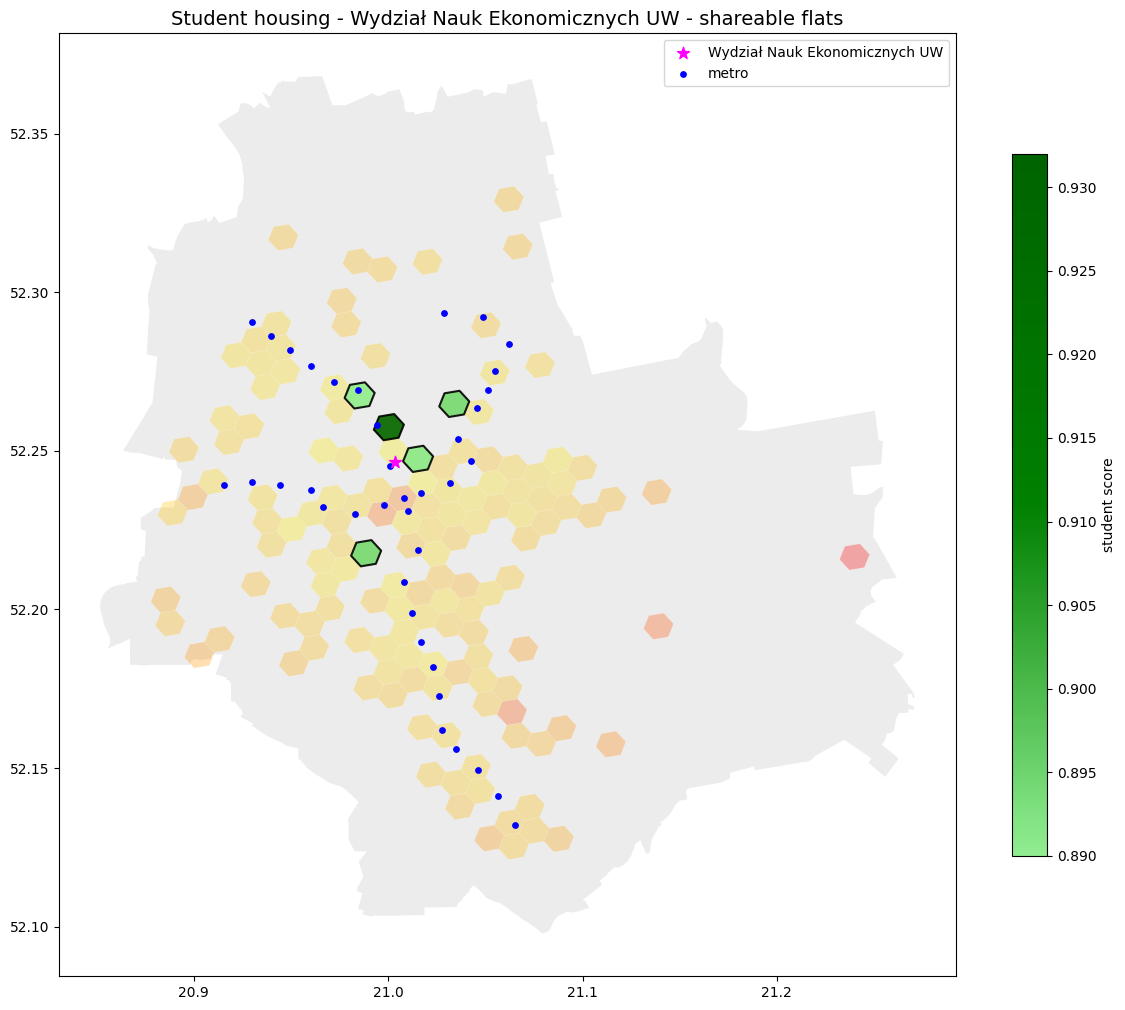


Top 3 listings per top 5 hexes:

Hex 881f53c8... - avg score 0.894
  [0.894] 2 pokoje - okolice Placu Hallera - Metro - loft
  2010 PLN/person (shared) | Praga Północ | https://www.otodom.pl/pl/oferta/2-pokoje-okolice-placu-hallera-metro-loft-ID4nZJV

Hex 881f53c9... - avg score 0.891
  [0.891] Stare Miasto I 2 pokoje I Metro
  2350 PLN/person (shared) | Śródmieście | https://www.otodom.pl/pl/oferta/stare-miasto-i-2-pokoje-i-metro-ID4AGbF

Hex 881f53c9... - avg score 0.894
  [0.894] Pl. Narutowicza 2pok 63m, wysoki standard, też na biuro, OD 
  2450 PLN/person (shared) | Ochota | https://www.otodom.pl/pl/oferta/pl-narutowicza-2pok-63m-wysoki-standard-tez-na-biuro-od-zaraz-ID4AGMp

Hex 881f53c9... - avg score 0.932
  [0.932] Metro Dw Gdański_apartament 2 pok_60m2__Panorama
  2350 PLN/person (shared) | Śródmieście | https://www.otodom.pl/pl/oferta/metro-dw-gdanski-apartament-2-pok-60m2-panorama-ID4AHUk

Hex 881f53cb... - avg score 0.890
  [0.89] Plac Wilsona, Żoliborz, 54 m² | 2 pokoje 

In [18]:
result = student_housing_query(
    university="Uniwersytet Warszawski",
    building="Wydział Nauk Ekonomicznych UW",
    flat_type="shareable",
    gdf_listings=gdf_listings,
    gdf_universities=gdf_universities,
    gdf_districts=gdf_districts,
    gdf_transport=gdf_transport,
    gdf_metro=gdf_metro,
    weight_affordability=0.40,
    weight_transit=0.40,
    weight_uni=0.20,
    weight_density=0.00,
)